<a href="https://colab.research.google.com/github/arulbenjaminchandru/ai-architect-program/blob/main/Zero_Cost_RAG_Pipeline_with_DeepSeek_R1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Implementing a Retrieval Augmented Generation (RAG) Pipeline with DeepSeek R1 in Google Colab**

**Author : Arul Benjamin Chandru E**

**Linkedin :** https://linkedin.com/in/arulbenjamin

This notebook outlines the implementation of a Retrieval Augmented Generation (RAG) pipeline using the DeepSeek R1 language model within the Google Colab environment. The pipeline leverages various libraries and techniques to achieve a robust and cost-effective RAG system.

**Key Processes:**

1. **Environment Setup:** Installing essential libraries like Langchain, Langchain-Community, Sentence Transformers, Faiss-gpu-cu11, and Pypdf using pip. These libraries facilitate tasks such as LLM interaction, document processing, and vector store creation.
2. **Understanding RAG:** Providing a comprehensive overview of the Retrieval Augmented Generation concept, including its definition, working process, benefits, and relevance to this notebook.
3. **Core Components and Libraries:** Introducing the primary components and libraries involved in the RAG pipeline, such as DeepSeek R1 (LLM), Langchain (framework), and Ollama (LLM runtime).
4. **Document Loading and Processing:** Loading external documents (likely in PDF format) using Pypdf and preparing them for further processing within the RAG pipeline.
5. **Embedding Generation:** Generating embeddings for the document content using Sentence Transformers. These embeddings represent the semantic meaning of the text and are crucial for similarity search.
6. **Vector Store Creation:** Creating a vector store (likely using Faiss-gpu-cu11) to efficiently store and search the document embeddings. This allows for quick retrieval of relevant documents based on user queries.
7. **Query Processing and Retrieval:** Processing user queries, generating their embeddings, and performing similarity searches within the vector store to retrieve the most relevant documents.
8. **Response Generation:** Utilizing DeepSeek R1, along with the retrieved documents as context, to generate informed and accurate responses to user queries. Langchain assists in orchestrating the interaction between DeepSeek R1 and the other components.
9. **Pipeline Orchestration:** Langchain serves as the backbone of the pipeline, seamlessly connecting all the steps and managing the flow of information between components. It allows users to effectively construct and run the RAG workflow within Google Colab.

##**1. Environment Setup**

Installing Langchain, Langchain-Community, Sentence Transformers, Faiss-gpu-cu11, and Pypdf using pip

In [1]:
!pip install -U langchain langchain-community langchain-text-splitters langchain-huggingface

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.2/121.2 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.4/236.4 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.7 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: langgraph
    Found existing installation: langgraph 1.2.1
    Uninstalling langgraph-1.2.1:
      Successfully uninstalled langgraph-1.2.1
  Attempting uninstall: langchain
    Found existing installation: langchain 1.3.1
    Uninstalling langchain-1.3.1:
      Successfully uninstalled langchain-1.3.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This beha

In [2]:
!pip install sentence-transformers

In [3]:
!pip install faiss-gpu-cu11

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 MB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 51.7 MB/s eta 0:00:00


In [4]:
!pip install pypdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.9/343.9 kB 10.6 MB/s eta 0:00:00


##2.**Retrieval Augmented Generation (RAG) - An Overview**

**What is RAG?**

Retrieval Augmented Generation (RAG) is a technique that enhances the capabilities of large language models (LLMs) by combining their generative power with the ability to retrieve relevant information from an external knowledge base.

**How does RAG work?**

Instead of relying solely on the information stored within the LLM's parameters, RAG allows the model to access and incorporate external knowledge. This is achieved through a two-step process:

**Retrieval:** When presented with a user query, RAG first retrieves relevant documents or snippets of information from the external knowledge base using a search engine or a similarity search algorithm.

**Generation:** The retrieved information is then used as context for the LLM, which generates a more informed and comprehensive response based on both its internal knowledge and the retrieved context.
Why is RAG useful?

RAG addresses several limitations of traditional LLMs, including:

**Limited Knowledge:** LLMs are trained on a massive but finite amount of data, which may not cover all possible topics or contain the most up-to-date information. RAG enables LLMs to access and utilize external knowledge, expanding their knowledge base and improving their ability to answer a wider range of questions.

**Hallucination:** LLMs can sometimes generate responses that are factually incorrect or inconsistent with the real world. RAG helps mitigate this issue by grounding the LLM's responses in relevant information retrieved from a reliable knowledge base.

**Adaptability:** RAG allows LLMs to be easily adapted to new domains or tasks by simply updating the external knowledge base. This makes RAG systems more flexible and scalable than traditional LLMs.

**In the context of this notebook:**

This notebook focuses on building a zero-cost RAG pipeline using DeepSeek R1, Langchain, and Ollama on Google Colab's free tier. It leverages these tools to load documents, generate embeddings, create a vector store, and integrate with the LLMs to build a robust RAG system. The T4 GPU provided by Colab's free tier enables efficient execution of the pipeline.

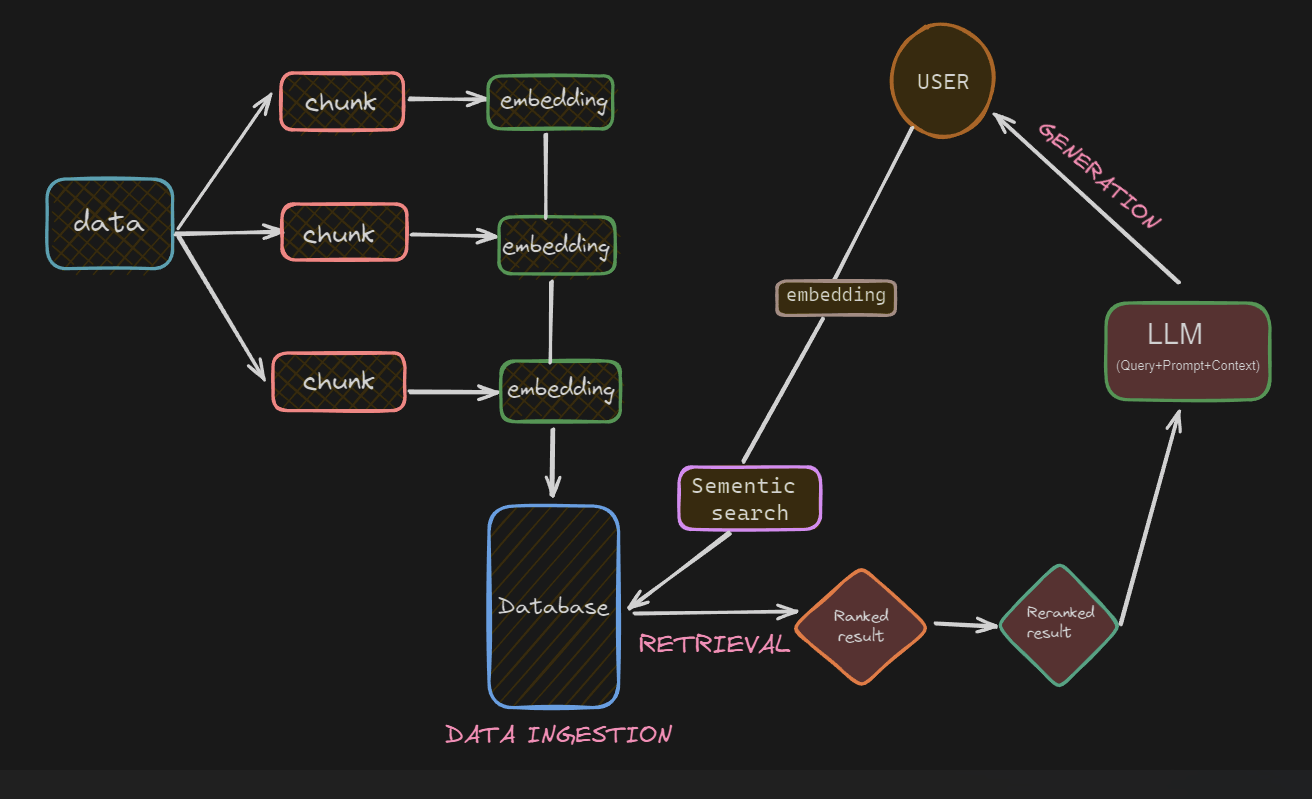

##**3.Importing required stuff**

In [5]:
# Document Loader
from langchain_community.document_loaders import PyPDFLoader

# Text Splitter
from langchain_text_splitters import CharacterTextSplitter

# Vector Store
from langchain_community.vectorstores import FAISS

# Embeddings
from langchain_huggingface import HuggingFaceEmbeddings

# Retrieval Chain
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings

/tmp/ipykernel_1534/1282599801.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


##**4.Loading the PDF Document**

In this section, we will load the PDF document containing the information we want to use as our knowledge base.

We will be using the `PyPDFLoader` class from the `langchain` library to accomplish this.

**Steps:**

1. **Import the `PyPDFLoader`:** We start by importing the necessary class from the `langchain` library.

2. **Create the loader object:** We then create an instance of the `PyPDFLoader` class, providing the path to our uploaded PDF file. Make sure to replace `"Resume.pdf"` with the actual file name of your uploaded PDF.

3. **Load the document:** Finally, we call the `load()` method on the loader object to load the PDF document into a list of `Document` objects. This list of documents will serve as our knowledge base.

**Note:**

* The uploaded PDF should be in the "Files" section of the Google Colab sidebar.
* You can change the file name as needed in the code above.

Now that we have loaded the document, we can proceed with the next steps in building our RAG pipeline, such as generating embeddings and creating a vector store.


In [6]:
from google.colab import files
import os

uploaded = files.upload()

# Get the filename of the uploaded PDF (assuming only one file is uploaded)
if uploaded:
    for filename in uploaded.keys():
        pdf_filename = filename
        print(f"Uploaded file: {pdf_filename}")
        # You can now use 'pdf_filename' to reference the uploaded file
        # For example, to load it with PyPDFLoader:
        # loader = PyPDFLoader(f"/content/{pdf_filename}")
        # documents = loader.load()
else:
    print("No file was uploaded.")

Saving Arul Benjamin Resume.pdf to Arul Benjamin Resume.pdf
Uploaded file: Arul Benjamin Resume.pdf


In [7]:
# Load document using PyPDFLoader document loader
# LLM dont know our personal information. So I am using my resume here.
# Upload the document under files section. The file name can be changed here.
loader = PyPDFLoader(pdf_filename)
documents = loader.load()
print(documents)

[Document(metadata={'producer': 'Microsoft® Word 2019', 'creator': 'Microsoft® Word 2019', 'creationdate': '2026-05-30T23:07:12+05:30', 'author': 'Arul Benjamin Chandru Ebenezer Vedanayagam', 'moddate': '2026-05-30T23:07:12+05:30', 'source': 'Arul Benjamin Resume.pdf', 'total_pages': 4, 'page': 0, 'page_label': '1'}, page_content='Arul Benjamin Chandru Ebenezer Vedanayagam \n   +91-9894481283 |       arulbenjaminchandru@gmail.com |     Chennai, Tamil Nadu \n \nENGINEERING MANAGER | FINTECH MODERNIZATION | GENERATIVE AI \nStrategic technology leader with 12+ years of experience driving large -scale FinTech \nmodernization and AI transformation  across banking, insurance, and telecom domains. \nCurrently leading an 84-member engineering team at Cognizant , delivering enterprise -\ngrade modernization programs and cloud -native innovations. Proven expertise in \nMainframe-to-Cloud migration, Java Microservices, and Generative AI  implementation \nusing IBM WatsonX and Google Cloud. Recogn

##**5.Splitting the data into chunks**

This code snippet uses the `CharacterTextSplitter` class from the `langchain` library to split a larger text into smaller, more manageable chunks. This is often a necessary step in Natural Language Processing (NLP) tasks to ensure efficient processing and avoid exceeding the input limitations of language models.

**Steps:**

1. **Import the necessary library:**
    - Make sure you have `langchain` installed. Install it using `!pip install langchain` if needed.
2. **Create the text splitter:**
   - This initializes a `CharacterTextSplitter` object with specific parameters:
     - `chunk_size=1000`: Sets the maximum size of each chunk to 1000 characters.
     - `chunk_overlap=30`: Specifies that consecutive chunks should overlap by 30 characters to maintain context.
     - `separator="\n"`: Indicates that the text should be split at newline characters (`\n`).
3. **Split the documents:**

`docs = text_splitter.split_documents(documents=documents)`

This applies the splitter to the documents variable (which presumably holds a list of text documents or a single large text) and stores the resulting chunks in the docs variable.


In [8]:
#Splitting the data into chunk
text_splitter = CharacterTextSplitter(chunk_size=1000, chunk_overlap=30, separator="\n")
docs = text_splitter.split_documents(documents=documents)

print(docs)

[Document(metadata={'producer': 'Microsoft® Word 2019', 'creator': 'Microsoft® Word 2019', 'creationdate': '2026-05-30T23:07:12+05:30', 'author': 'Arul Benjamin Chandru Ebenezer Vedanayagam', 'moddate': '2026-05-30T23:07:12+05:30', 'source': 'Arul Benjamin Resume.pdf', 'total_pages': 4, 'page': 0, 'page_label': '1'}, page_content='Arul Benjamin Chandru Ebenezer Vedanayagam \n   +91-9894481283 |       arulbenjaminchandru@gmail.com |     Chennai, Tamil Nadu \n \nENGINEERING MANAGER | FINTECH MODERNIZATION | GENERATIVE AI \nStrategic technology leader with 12+ years of experience driving large -scale FinTech \nmodernization and AI transformation  across banking, insurance, and telecom domains. \nCurrently leading an 84-member engineering team at Cognizant , delivering enterprise -\ngrade modernization programs and cloud -native innovations. Proven expertise in \nMainframe-to-Cloud migration, Java Microservices, and Generative AI  implementation \nusing IBM WatsonX and Google Cloud. Recogn

##**6.Embedding the chuked texts using MTEB: Massive Text Embedding Benchmark**

The all-mpnet-base-v2 model provides the best quality, while all-MiniLM-L6-v2 is 5 times faster and still offers good quality.

BGE(BAAI general embedding)
BAAI: https://huggingface.co/BAAI

**Dataset size:**  Larger datasets generally benefit from more powerful models like MPNet.

**Computational resources:**  If you have limited resources, BGE Small En or MiniLM might be better options.

**Task complexity:**  For complex tasks like question answering or text summarization, MPNet is often preferred.

**Embedding dimensionality:**  Different models produce embeddings of varying dimensions.Choose based on downstream task requirements.

**Performance vs. efficiency trade-off:** Decide if you prioritize high accuracy or faster processing

#####Experimentation is key. Try different models and evaluate their performance on your specific task and dataset to find the best fit.

MPNET: Masked and Permuted Pre-training for Language Understanding.

https://huggingface.co/sentence-transformers

https://huggingface.co/spaces/mteb/leaderboard

https://huggingface.co/blog/mteb


In [9]:
#loading the embedding model from huggingface
embedding_model_name = "sentence-transformers/all-mpnet-base-v2"
model_kwargs = {"device": "cuda"}
embeddings = HuggingFaceEmbeddings(
  model_name=embedding_model_name,
  model_kwargs=model_kwargs
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

##**7. Storing the embeddings in FAISS vector DB locally**

Here the chunked embeddings are stored in the form of vector store in FAISS DB. It will create a folder named faiss_index_ and with at it stores all the chunked data. On top of that, retriever will be serving as the data retriever from DB.

# Why Use FAISS

1. Efficiency
2. Versatility
3. Scalability
4. Integration
5. GPU Support

# Security Considerations

1. Data Control
2. Reduced Exposure
3. Compliance
4. Latency and Performance
5. Network Security

In [10]:

from langchain_community.vectorstores import FAISS


In [11]:
#loading the data and correspond embedding into the FAISS
vectorstore = FAISS.from_documents(docs, embeddings)
retriever=vectorstore.as_retriever()


In [12]:
# Persist the vectors locally on disk
vectorstore.save_local("faiss_index_")

In [13]:
# Load from local storage
persisted_vectorstore = FAISS.load_local("faiss_index_", embeddings,allow_dangerous_deserialization=True)

In [14]:
#creating a retriever on top of database
retriever = persisted_vectorstore.as_retriever()

##**8.Installing Ollama Langchain support**

In [15]:
!pip install langchain_ollama

##**9. Run Ollama inside google colab using its own builtin linux xterm**

In [16]:
!pip install colab-xterm #https://pypi.org/project/colab-xterm/
%load_ext colabxterm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.6/115.6 kB 6.1 MB/s eta 0:00:00


##**10. Launch xterm with the command**

Launch xterm which is built in on Google Colab by using `%xterm` command.

1. Install Ollama by using the following command

   `curl -fsSL https://ollama.com/install.sh | sh`

2. Start the ollama server by running
   `ollama serve`. Now this window we need to use it as ollama server here.

In [18]:
%xterm

Launching Xterm...

<IPython.core.display.Javascript object>

##**11. Pull Deepseek R1 model**

1. Open another `%xterm` terminal
2. Run the following command inside terminal which can pull the Deepseek R1 model to your local colab disk.
`ollama run deepseek-r1`

In [19]:
%xterm

## ollama run deepseek-r1

Launching Xterm...

<IPython.core.display.Javascript object>

##**12. Accessing Ollama using Python**

1. Import Ollama library
2. Initialize the Ollama model. In our case, it will be Deepseek R1 (deepseek-r1)
3. Invoke the model directly without any RAG data and see what response we are getting back.

In [20]:
from langchain_community.llms import Ollama

In [21]:
# Initialize an instance of the Ollama model
llm = Ollama(model="deepseek-r1")

/tmp/ipykernel_1534/3720593735.py:2: LangChainDeprecationWarning: The class `Ollama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the `langchain-ollama package and should be used instead. To use it run `pip install -U `langchain-ollama` and import as `from `langchain_ollama import OllamaLLM``.
  llm = Ollama(model="deepseek-r1")


In [23]:
# Invoke the model to generate responses
response = llm.invoke("Who is Arul Benjamin Chandru?")
print(response)

Based on available information, **Arul Benjamin Chandru**, often known professionally as **A. B. Chandru**, is a prominent **Tamil film director, screenwriter, and producer**.

Here are the key points about him:

1.  **Profession:** He works in the Tamil film industry (Kollywood).
2.  **Notable Films (Director):**
    *   **Debut:** *Engey* (2007)
    *   *Vettai* (2012)
    *   *Kaththi* (2015) - A major blockbuster superhero film.
    *   *Aaranya Kaattalai* (2016)
    *   *Suriyan* (2019)
    *   *Aaranya Kattalai* (2016) - Sequel to *Kaththi*.
3.  **Notable Films (Producer):**
    *   *Master* (2021) - A highly successful film starring Rajinikanth.
4.  **Background:** He was born on June 19, 1979, in Chennai, Tamil Nadu.
5.  **Style:** Known for directing action-packed, commercial, and often visually striking films.

In summary, A. B. Chandru is a well-known and successful director and producer in the Tamil film industry, famous for his work on films like *Vettai*, *Kaththi*, and *

##**13. Buiding a retrieval QA chain**

Here we can use the RAG data which is from FAISS vector and ask the question to the chain. Now we will get the relevant response to the data which we are providing.

In [24]:
 #Use RetrievalQA chain for orchestration
#qa = RetrievalQA.from_chain_type(llm=llm, chain_type="stuff", retriever=retriever)
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser


prompt = ChatPromptTemplate.from_template(
    """Answer the question based only on the context:

    {context}

    Question: {question}
    """
)

# LCEL Chain
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

rag_chain = (
    {
        "context": retriever | format_docs,
        "question": lambda x: x
    }
    | prompt
    | llm
    | StrOutputParser()
)

In [26]:
while True:
  query = input("Type your query if you want to exit type Exit: \n")
  if query == "Exit":
    break
  result = rag_chain.invoke(query)
  print(result)

Type your query if you want to exit type Exit: 
what is his email address?
Arul Benjamin Chandru Ebenezer Vedanayagam's email address is **arulbenjaminchandru@gmail.com**.
Type your query if you want to exit type Exit: 
Exit
